In [14]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
import nibabel as nib

In [6]:
real = np.load("lung_mean_occupancy_heatmap_128_256_256.npy")
print(real.shape)
synthetic = np.load("maisi_heatmap.npy").transpose(2, 1, 0)
print(synthetic.shape)

(128, 256, 256)
(128, 256, 256)


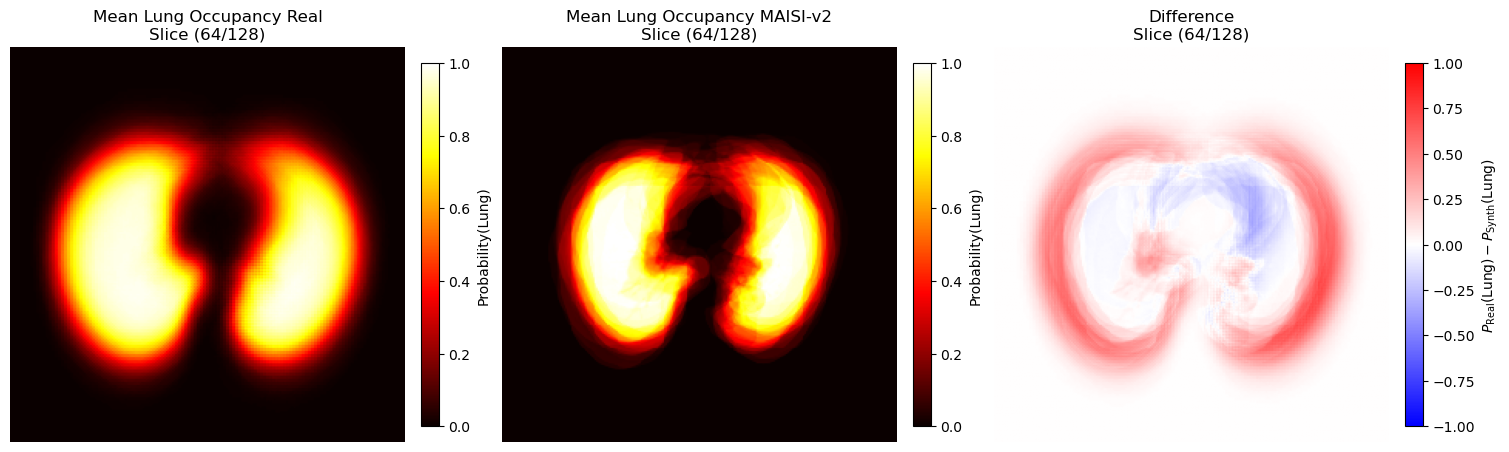

In [8]:
slice_idx = 64
n_slices = real.shape[0]
difference = real - synthetic

fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

images = [
    axes[0].imshow(real[slice_idx], cmap="hot", vmin=0, vmax=1),
    axes[1].imshow(synthetic[slice_idx], cmap="hot", vmin=0, vmax=1),
    axes[2].imshow(difference[slice_idx], cmap="bwr", vmin=-1, vmax=1),
]

titles = [
    "Mean Lung Occupancy Real",
    "Mean Lung Occupancy MAISI-v2",
    "Difference",
]

labels = [
    "Probability(Lung)",
    "Probability(Lung)",
    r"$P_{\mathrm{Real}}(\mathrm{Lung}) - P_{\mathrm{Synth}}(\mathrm{Lung})$",
]

for ax, im, title, label in zip(axes, images, titles, labels):
    ax.set_title(f"{title}\nSlice ({slice_idx}/{n_slices})")
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label=label)

# Optional: save before showing
# fig.savefig("mean_lung_occupancy_comparison.png", dpi=300, bbox_inches="tight")

plt.show()

In [42]:
eps = 1e-8

mae = np.mean(np.abs(synthetic - real))
rmse = np.sqrt(np.mean((synthetic - real) ** 2))
corr = np.corrcoef(synthetic.flatten(), real.flatten())[0, 1]

In [43]:
P = real / (real.sum() + eps)
Q = synthetic / (synthetic.sum() + eps)
M = 0.5 * (P + Q)
js_div = 0.5 * (np.sum(P * np.log((P + eps)/(M + eps))) + np.sum(Q * np.log((Q + eps)/(M + eps))))

In [44]:
threshold = 0.5  # Binarize heatmaps
R = (real >= threshold).astype(np.uint8)
S = (synthetic >= threshold).astype(np.uint8)

dice = 2 * (R & S).sum() / (R.sum() + S.sum() + eps)

In [45]:
from scipy.spatial.distance import directed_hausdorff
coords_r = np.argwhere(R)
coords_s = np.argwhere(S)
hd = max(
    directed_hausdorff(coords_r, coords_s)[0],
    directed_hausdorff(coords_s, coords_r)[0]
)

In [13]:
lung_occupancy = synthetic.sum()/synthetic.size
print(f"Lung Occupancy: {lung_occupancy:.4f}")

Lung Occupancy: 0.0917


In [37]:
MASKS_DIR = Path("Z:/nas-ctm01/datasets/public/LungNodule-nifti/preprocessed/MAISI/results_synth_maskct/masks_132_without_tumor")
MASKS_DIR = Path("converted/")
LUNG_LOBE_LABELS = [28, 29, 30, 31, 32]
ANATOMY_LABELS = {
    28: "Left Upper Lobe",
    29: "Left Lower Lobe",
    30: "Right Upper Lobe",
    31: "Right Middle Lobe",
    32: "Right Lower Lobe",
}

In [38]:
mask_paths = sorted(path for path in MASKS_DIR.iterdir()
                        if path.is_file() and path.name.lower().endswith((".nii", ".nii.gz")))
print(f"Found {len(mask_paths)} mask files in {MASKS_DIR}")

Found 3 mask files in converted


In [39]:
lung_percentages = []
bg_percentages = []

for mask_path in tqdm(mask_paths, desc="Calculating percentages"):
    mask = nib.load(mask_path).get_fdata()
    binary_mask = np.isin(mask, list(ANATOMY_LABELS)).astype(np.uint8)

    lung_voxels = np.sum(binary_mask)
    total_voxels = np.prod(binary_mask.shape)
    lung_percentages.append(100 * lung_voxels / total_voxels)
    bg_percentages.append(100 * (total_voxels - lung_voxels) / total_voxels)

Calculating percentages: 100%|██████████| 3/3 [00:06<00:00,  2.27s/it]


In [40]:
np.shape(lung_percentages), np.shape(bg_percentages)

((3,), (3,))

In [41]:
lung_mean = np.mean(lung_percentages)
lung_std = np.std(lung_percentages, ddof=1) if len(lung_percentages) > 1 else np.nan
bg_mean = np.mean(bg_percentages)
bg_std = np.std(bg_percentages, ddof=1) if len(bg_percentages) > 1 else np.nan


print(f"\n{'Region':<15} {'Mean (%)':>18} {'Std (pp)':>18}")
print("-" * 53)
print(f"{'Total lung':<15} {lung_mean:>18.2f} {lung_std:>18.2f}")
print(f"{'Background':<15} {bg_mean:>18.2f} {bg_std:>18.2f}")


Region                    Mean (%)           Std (pp)
-----------------------------------------------------
Total lung                    9.91               2.70
Background                   90.09               2.70


In [46]:
rows = [
    ("MAE(↓)", f"{mae:.4f}"),
    ("RMSE(↓)", f"{rmse:.4f}"),
    ("Corr.(↑)", f"{corr:.4f}"),
    ("JSD(↓)", f"{js_div:.4f}"),
    ("HD95(↓)", f"{hd:.2f}"),
    ("Lung Dice(↑)", f"{dice:.4f}"),
    ("Lung Vol. (%)", f"{lung_mean:.2f}±{lung_std:.2f}"),
    ("Background Vol. (%)", f"{bg_mean:.2f}±{bg_std:.2f}"),
]

print(f"{'Metric':<23} {'MAISI-v2':>16}")
print("-" * 40)
for metric, value in rows:
    print(f"{metric:<23} {value:>16}")
print("-" * 40)

Metric                          MAISI-v2
----------------------------------------
MAE(↓)                            0.0858
RMSE(↓)                           0.1877
Corr.(↑)                          0.7350
JSD(↓)                            0.1396
HD95(↓)                            38.78
Lung Dice(↑)                      0.6015
Lung Vol. (%)                  9.91±2.70
Background Vol. (%)           90.09±2.70
----------------------------------------
